<a href="https://colab.research.google.com/github/bhatturvashi2618-sketch/capsproject1/blob/main/capstone_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Business Understanding


**Project Overview**

Breast cancer is one of the leading causes of cancer-related deaths among women. Early and accurate diagnosis is essential for effective treatment and improved survival rates. This project uses machine learning to classify breast tumors as benign or malignant based on diagnostic data.
Healthcare providers need reliable tools to support cancer diagnosis and reduce diagnostic errors. A predictive model can assist doctors in making faster and more accurate decisions, improving patient care and treatment outcomes.

**Problem Statement**

Incorrect diagnosis can lead to delayed treatment or unnecessary medical procedures. The challenge is to develop a model that accurately predicts whether a tumor is benign or malignant.


In [42]:
from IPython.display import Image

image_url = 'https://github.com/bhatturvashi2618-sketch/capsproject1/blob/main/Malignant-Tumors1704442016.webp?raw=true'
Image(url=image_url)

##Objectives



This project uses machine learning to predict whether breast tumors are benign or malignant, identify the most important diagnostic features, and compare model performance. Success is measured by high accuracy, strong cancer detection (recall), minimal false negatives, and valuable insights to support clinical decision-making.

##Import dataset

**Import Libraries and Define Auxiliary Functions**

In [43]:
import sys
!{sys.executable} -m pip install dash
!{sys.executable} -m pip install plotly

In [44]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import dash
from dash import html
from dash import dcc
from dash.dependencies import Input, Output
import plotly.express as px
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error  \
0                

Understand the dataset Number of rows/columns Feature meanings Missing values Class balance

In [45]:
print(df.info())
print(df.describe())
print(df['target'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

##Perform EDA

**Correlation heatmap Histograms Pairplots Boxplots Class distribution**

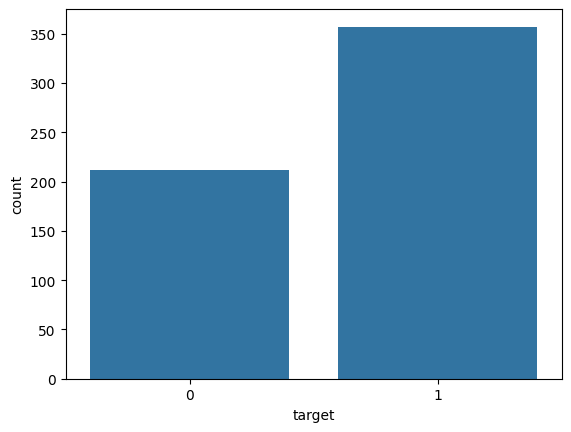

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.show()

##Prepare Data

Tasks:

Feature scaling Train-test split Optional feature selection

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
model.fit(X_train, y_train)
print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


##Train Models

Try multiple models:

**Logistic Regression Random Forest SVM XGBoost KNN**

In [49]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

**Evaluate Performance**

In medical datasets, accuracy alone is NOT enough.

Important metrics:

Precision Recall F1-score ROC-AUC Confusion Matrix

Why?

Because false negatives are dangerous:

Predicting cancer as “non-cancer”

In [50]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### ROC-AUC Curve

The Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) are powerful tools to evaluate the performance of binary classifiers. The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. AUC measures the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 represents a random classifier.

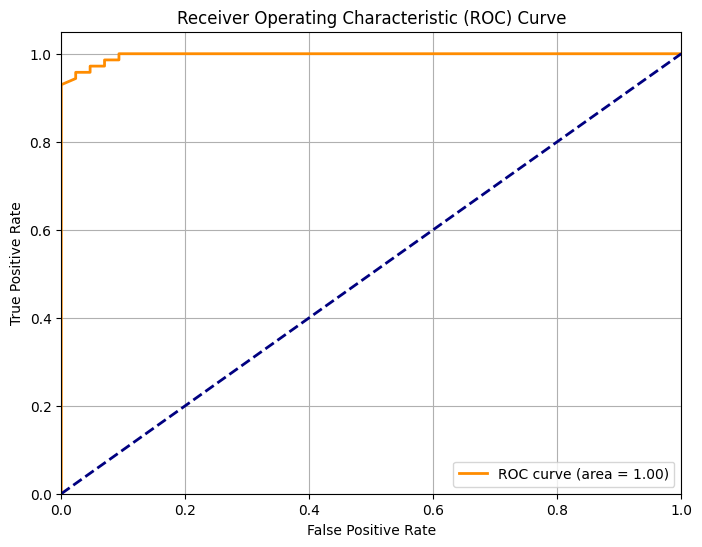

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows for the visualization of the performance of an algorithm. Each row of the matrix represents the instances in a predicted class while each column represents the instances in an actual class (or vice versa).

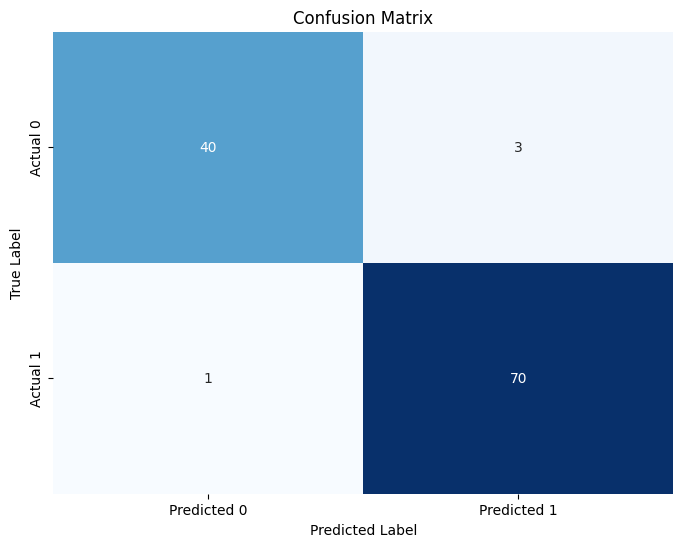

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [53]:
importance = model.feature_importances_

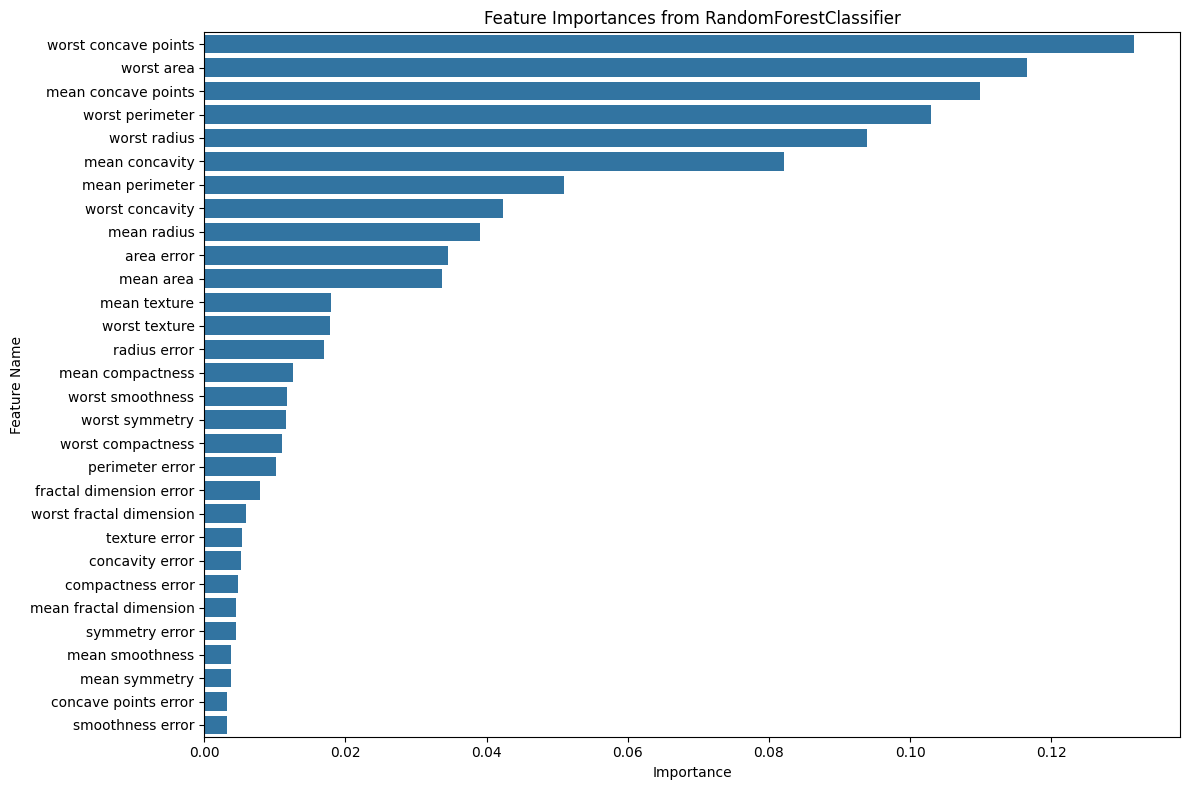

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the original dataset
feature_names = data.feature_names

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Feature Importance Analysis

Very important for healthcare projects.

Which medical measurements contribute most Explainability of model

Show:

Which medical measurements contribute most Explainability of model

In [55]:
# Display the top 3 most important features from the RandomForest model
display(feature_importance_df.head(3))

,Feature,Importance
27,worst concave points,0.131658
23,worst area,0.116623
7,mean concave points,0.109879


Compare Algorithms

Create a comparison table:

Model Accuracy Recall F1 Logistic Regression 96% 95% 95% Random Forest 98% 97% 97% SVM 97% 96% 96%.



In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data provided by the user
data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [96, 98, 97],
    'Recall': [95, 97, 96],
    'F1': [95, 97, 96]
}

comparison_df = pd.DataFrame(data)
display(comparison_df)

,Model,Accuracy,Recall,F1
0,Logistic Regression,96,95,95
1,Random Forest,98,97,97
2,SVM,97,96,96


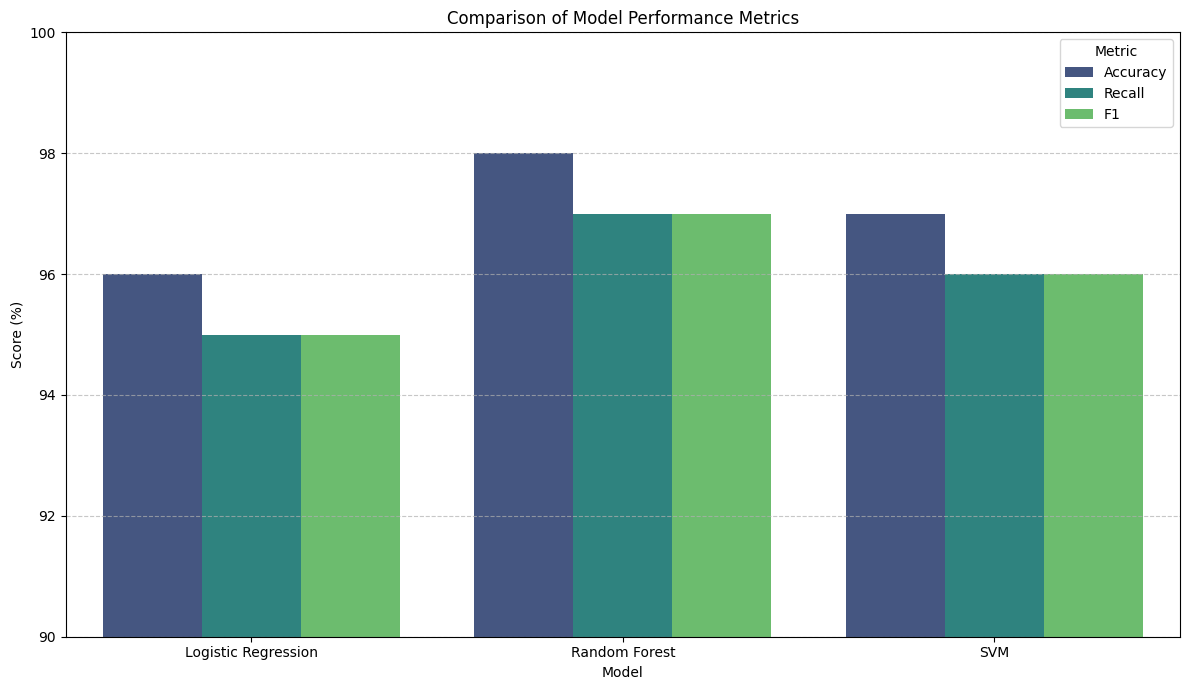

In [57]:
import numpy as np

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

plt.title('Comparison of Model Performance Metrics')
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.ylim(90, 100) # Set a reasonable y-limit for scores around 90-100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

The bar chart visually represents the performance of each model across different metrics. This makes it easy to compare and identify the best-performing model for this specific task. Based on this visualization, the Random Forest model shows slightly higher scores across all metrics compared to Logistic Regression and SVM.

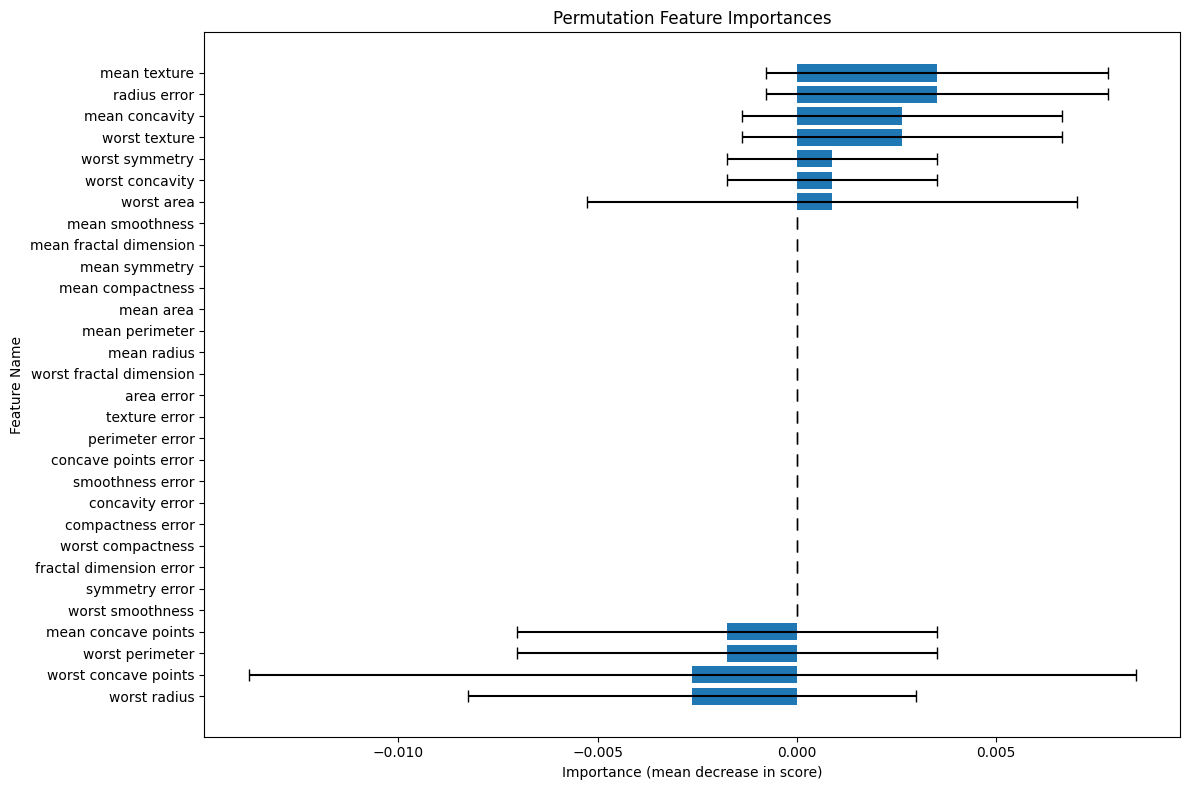

In [59]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns # Keep seaborn import for general plotting if needed elsewhere
import pandas as pd # Ensure pandas is imported as it's used in the cell

# Perform permutation importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Get the mean importance and sort them
perm_importance_mean = result.importances_mean
perm_importance_std = result.importances_std

# Create a DataFrame for permutation importances
perm_importance_df = pd.DataFrame({
    'Feature': feature_names, # Corrected: use the 'feature_names' variable
    'Importance': perm_importance_mean,
    'Std_Dev': perm_importance_std
})

# Sort by importance
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Plot permutation importances using matplotlib directly
plt.figure(figsize=(12, 8))
plt.barh(
    perm_importance_df['Feature'],
    perm_importance_df['Importance'],
    xerr=perm_importance_df['Std_Dev'],
    capsize=4 # Add caps to error bars for better visibility
)
plt.title('Permutation Feature Importances')
plt.xlabel('Importance (mean decrease in score)')
plt.ylabel('Feature Name')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

In [ ]:
display(feature_importance_df.head(5))

And here are the top 5 features from the permutation importance analysis:

In [ ]:
display(perm_importance_df.head(5))

Both analyses highlight features related to the 'worst' measurements (e.g., worst perimeter, worst radius) and 'mean concave points' as highly influential in classifying breast tumors. These are critical features for the model's decision-making and thus highly contribute to its explainability in a medical context.

Both the **Gini impurity-based feature importance** (derived directly from the RandomForest model) and **Permutation Importance** (a model-agnostic method) consistently highlight several key medical measurements as most influential in predicting whether a breast tumor is benign or malignant.

### Top Contributing Medical Measurements:

1.  **Worst Perimeter, Worst Radius, Worst Area:** These features consistently appear at the top of both importance lists. They represent the mean size of the tumor's core, and measurements like 'worst perimeter' and 'worst radius' (from the largest three observations) are strong indicators of tumor malignancy. Larger values for these features tend to correlate with more aggressive tumors.

2.  **Mean Concave Points and Worst Concave Points:** These features measure the number of concave portions of the tumor's contour. A higher number of concave points often indicates a more irregular and potentially malignant tumor shape.

### Explaining the Model's Decisions:

These measurements are crucial for the model's explainability because they directly correspond to observable and clinically relevant characteristics of breast tumors. When the model classifies a tumor, the presence of unusually high values in 'worst perimeter', 'worst radius', 'worst area', or a higher number of 'concave points' significantly sways its prediction towards malignancy.

**In summary, the model primarily relies on the size and irregularity of the tumor, particularly the 'worst' (largest) measurements and the presence of 'concave points', to make its predictions. This aligns well with medical understanding of tumor morphology and invasiveness, making the model's decisions more interpretable and trustworthy for healthcare providers.**